数据集前5行：
   person_id  gender  age     occupation  sleep_duration  sleep_quality  \
0          1    Male   29   Manual Labor             7.4            7.0   
1          2  Female   43        Retired             4.2            4.9   
2          3    Male   44        Retired             6.1            6.0   
3          4    Male   29  Office Worker             8.3           10.0   
4          5    Male   67        Retired             9.1            9.5   

   physical_activity_level  stress_level bmi_category blood_pressure  \
0                       41             7        Obese         124/70   
1                       41             5        Obese         131/86   
2                      107             4  Underweight         122/70   
3                       20            10        Obese         124/72   
4                       19             4   Overweight         133/78   

   heart_rate  daily_steps sleep_disorder  
0          91         8539            NaN  
1          81       

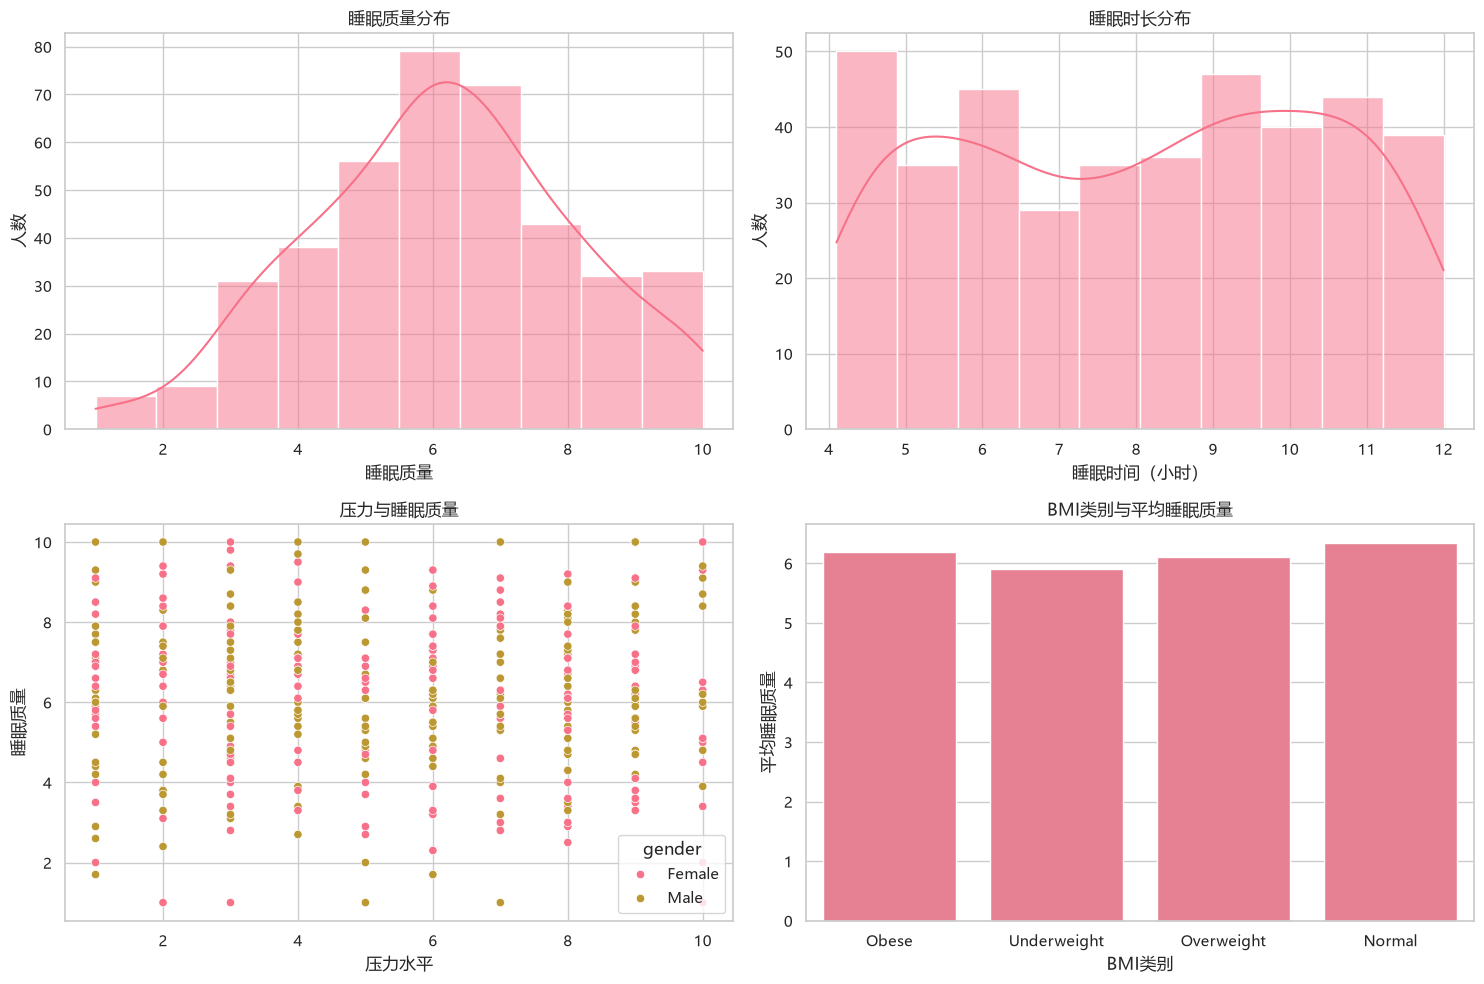

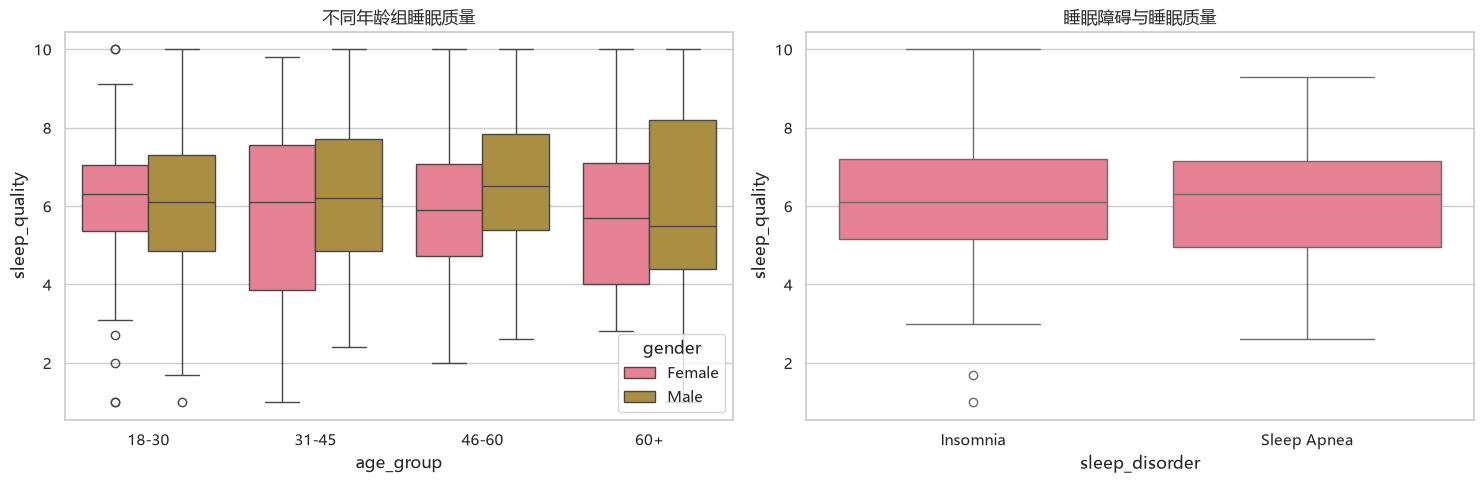

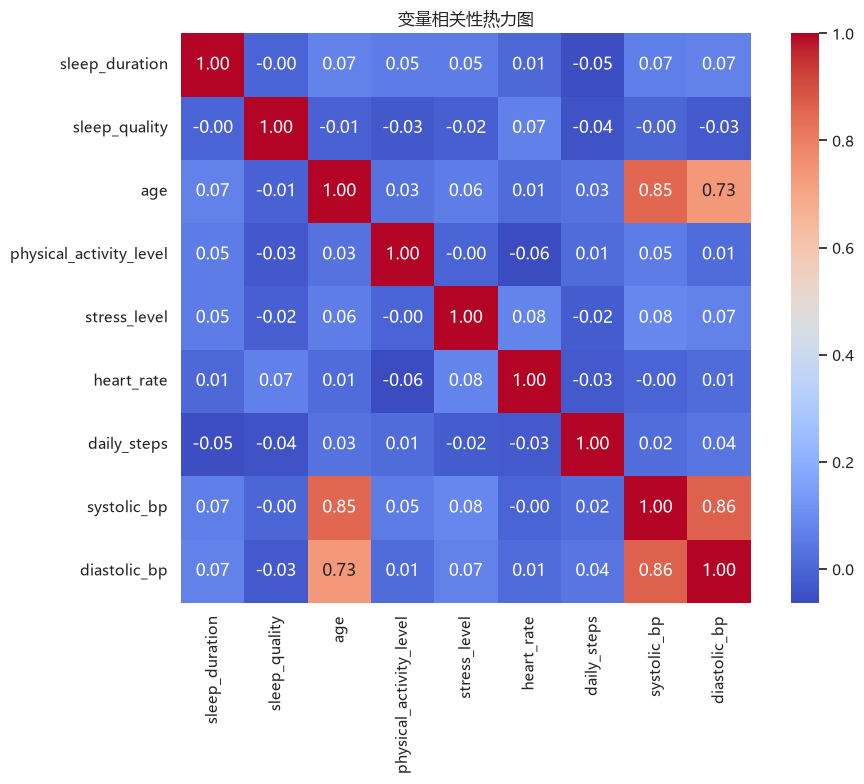

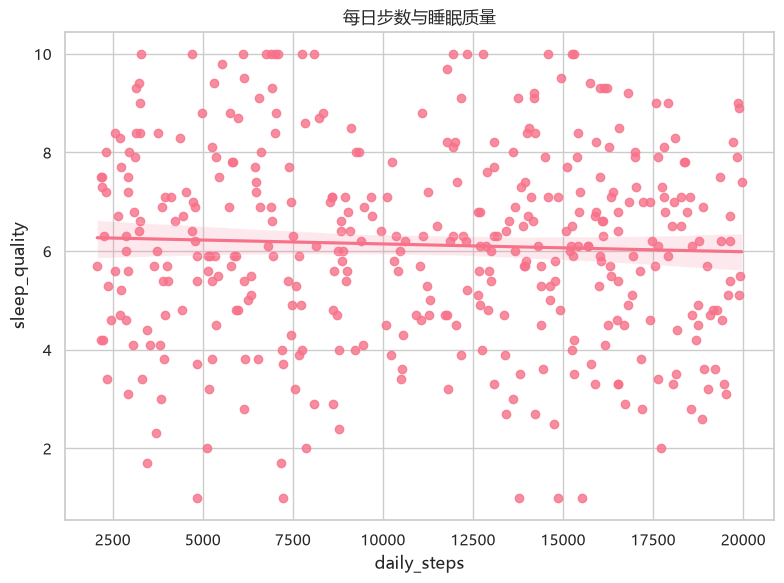

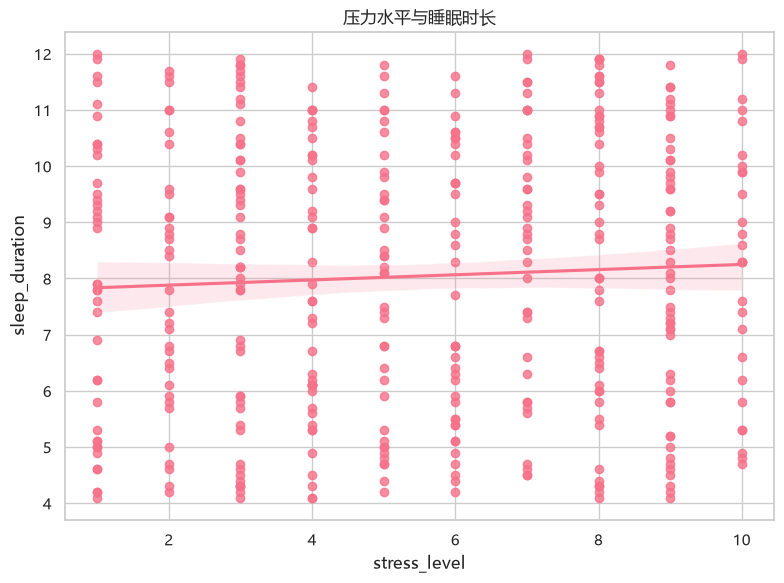


数据分析完成！
处理后的数据已保存为 cleaned_sleep_data.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# 设置可视化风格
# ==========================
sns.set_theme(style="whitegrid", palette="husl")

# Windows 中文显示
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# ==========================
# 1. 数据加载
# ==========================
sleep_data = pd.read_csv("data/sleep.csv")

print("数据集前5行：")
print(sleep_data.head())

print("\n数据集信息：")
sleep_data.info()

# ==========================
# 2. 数据清洗
# ==========================
print("\n每列缺失值数量：")
print(sleep_data.isnull().sum())

sleep_clean = sleep_data.copy()

# ==========================
# 3. 数据预处理
# ==========================

# 性别转换为分类变量
sleep_clean["gender"] = sleep_clean["gender"].astype("category")

# 血压拆分
bp = sleep_clean["blood_pressure"].str.split("/", expand=True)

sleep_clean["systolic_bp"] = pd.to_numeric(bp[0])
sleep_clean["diastolic_bp"] = pd.to_numeric(bp[1])

# 睡眠质量分类
bins = [0, 4, 7, 10]
labels = ["差", "中", "优"]

sleep_clean["sleep_quality_category"] = pd.cut(
    sleep_clean["sleep_quality"],
    bins=bins,
    labels=labels
)

# 年龄分组
age_bins = [0, 30, 45, 60, 100]
age_labels = ["18-30", "31-45", "46-60", "60+"]

sleep_clean["age_group"] = pd.cut(
    sleep_clean["age"],
    bins=age_bins,
    labels=age_labels
)

# ==========================
# 4. 描述性统计
# ==========================

print("\n数值变量统计：")
print(sleep_clean.describe())

print("\n性别统计：")
print(sleep_clean["gender"].value_counts())

print("\nBMI类别统计：")
print(sleep_clean["bmi_category"].value_counts())

print("\n睡眠障碍统计：")
print(sleep_clean["sleep_disorder"].value_counts())

# ==========================
# 5. 睡眠质量分析
# ==========================

gender_stats = (
    sleep_clean.groupby("gender", observed=True)
    .agg({
        "sleep_duration": "mean",
        "sleep_quality": "mean",
        "stress_level": "mean"
    })
    .round(2)
)

print("\n按性别统计：")
print(gender_stats)

bmi_stats = (
    sleep_clean.groupby("bmi_category", observed=True)
    .agg({
        "sleep_duration": "mean",
        "sleep_quality": "mean",
        "physical_activity_level": "mean"
    })
    .round(2)
)

print("\n按BMI类别统计：")
print(bmi_stats)

# ==========================
# 6. 睡眠障碍分析
# ==========================

disorder_stats = (
    sleep_clean.groupby("sleep_disorder", observed=True)
    .agg({
        "sleep_duration": ["mean", "count"],
        "sleep_quality": "mean",
        "age": "mean",
        "stress_level": "mean"
    })
    .round(2)
)

print("\n按睡眠障碍统计：")
print(disorder_stats)

# ==========================
# 7. 相关性分析
# ==========================

corr_columns = [
    "sleep_duration",
    "sleep_quality",
    "age",
    "physical_activity_level",
    "stress_level",
    "heart_rate",
    "daily_steps",
    "systolic_bp",
    "diastolic_bp"
]

correlation = sleep_clean[corr_columns].corr()

print("\n相关性矩阵：")
print(correlation)

# ==========================
# 8. 多因素分析
# ==========================

gender_age_stats = (
    sleep_clean.groupby(
        ["gender", "age_group"],
        observed=True
    )
    .agg({
        "sleep_duration": "mean",
        "sleep_quality": "mean",
        "stress_level": "mean"
    })
    .round(2)
)

print("\n按性别和年龄组统计：")
print(gender_age_stats)

occupation_bmi_stats = (
    sleep_clean.groupby(
        ["occupation", "bmi_category"],
        observed=True
    )
    .agg({
        "sleep_duration": "mean",
        "sleep_quality": "mean"
    })
    .round(2)
)

print("\n按职业和BMI类别统计：")
print(occupation_bmi_stats)

# ==========================
# 9. 数据可视化
# ==========================

plt.figure(figsize=(15, 10))

# 睡眠质量分布
plt.subplot(2, 2, 1)

sns.histplot(
    data=sleep_clean,
    x="sleep_quality",
    bins=10,
    kde=True
)

plt.title("睡眠质量分布")
plt.xlabel("睡眠质量")
plt.ylabel("人数")

# 睡眠时间分布
plt.subplot(2, 2, 2)

sns.histplot(
    data=sleep_clean,
    x="sleep_duration",
    bins=10,
    kde=True
)

plt.title("睡眠时长分布")
plt.xlabel("睡眠时间（小时）")
plt.ylabel("人数")

# 睡眠质量与压力
plt.subplot(2, 2, 3)

sns.scatterplot(
    data=sleep_clean,
    x="stress_level",
    y="sleep_quality",
    hue="gender"
)

plt.title("压力与睡眠质量")
plt.xlabel("压力水平")
plt.ylabel("睡眠质量")

# BMI与睡眠质量
plt.subplot(2, 2, 4)

sns.barplot(
    data=sleep_clean,
    x="bmi_category",
    y="sleep_quality",
    errorbar=None
)

plt.title("BMI类别与平均睡眠质量")
plt.xlabel("BMI类别")
plt.ylabel("平均睡眠质量")

plt.tight_layout()
plt.show()

# ==========================
# 10. 更多可视化
# ==========================

plt.figure(figsize=(15, 5))

# 年龄组睡眠质量
plt.subplot(1, 2, 1)

sns.boxplot(
    data=sleep_clean,
    x="age_group",
    y="sleep_quality",
    hue="gender"
)

plt.title("不同年龄组睡眠质量")

# 睡眠障碍
plt.subplot(1, 2, 2)

sns.boxplot(
    data=sleep_clean,
    x="sleep_disorder",
    y="sleep_quality"
)

plt.title("睡眠障碍与睡眠质量")

plt.tight_layout()
plt.show()

# ==========================
# 11. 相关性热力图
# ==========================

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("变量相关性热力图")

plt.tight_layout()
plt.show()

# ==========================
# 12. 每日步数与睡眠质量
# ==========================

plt.figure(figsize=(8, 6))

sns.regplot(
    data=sleep_clean,
    x="daily_steps",
    y="sleep_quality"
)

plt.title("每日步数与睡眠质量")

plt.tight_layout()
plt.show()

# ==========================
# 13. 压力水平与睡眠时长
# ==========================

plt.figure(figsize=(8, 6))

sns.regplot(
    data=sleep_clean,
    x="stress_level",
    y="sleep_duration"
)

plt.title("压力水平与睡眠时长")

plt.tight_layout()
plt.show()

# ==========================
# 14. 保存数据
# ==========================

sleep_clean.to_csv(
    "cleaned_sleep_data.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n数据分析完成！")
print("处理后的数据已保存为 cleaned_sleep_data.csv")